# About

This jupyter notebook is (one of) the first steps in the pipeline for the human_microbiome_compendium analysis.

Below contains the pipeline for loading the raw data, doing the appropriate filtering, and outputting the dataset files necessary for training & invoking the downstream models.

The dataset name is `v3v4_split_multiproj`.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from common.preprocess import *

In [3]:
""" cache directory. """
NOTEBOOK_CACHE = Path("/data/bwh-comppath-seq/youn/human_microbiome_compendium") / "v3v4_split_multiproj"
NOTEBOOK_CACHE.mkdir(exist_ok=True, parents=True)

""" Huggingface token """
with open("hf_token.txt", "rt") as f:
    token = f.readline().strip()
    assert len(token) > 0, "File 'hf_token.txt' should contain the hugging face token in the first line."
    os.environ["HF_TOKEN"] = token
    print("Successfully set huggingface token from file 'hf_token.txt'!")

Successfully set huggingface token from file 'hf_token.txt'!


# Dataset Files

File locations and metadata.

In [4]:
data_base_dir = Path("/data/cctm/youn/human_microbiome_compendium")

project_metadata_file = data_base_dir / "projects.csv"
asv_sequence_file = data_base_dir / "obs_md.txt.zst"  # tsv format: ASV_NAME    ASV_SEQ, has a header.
abundance_table_dir = data_base_dir / "asv"
sample_metadata_file = data_base_dir / "sample_metadata.tsv"

assert asv_sequence_file.exists(), f"Expected {asv_sequence_file} to exist."
assert asv_sequence_file.is_file(), f"Expected {asv_sequence_file} to be a file."
assert abundance_table_dir.exists(), f"Expected {asv_sequence_file} to exist."
assert abundance_table_dir.is_dir(), f"Expected {abundance_table_dir} to be a directory."
assert sample_metadata_file.exists(), f"Expected {sample_metadata_file} to exist."
assert sample_metadata_file.is_file(), f"Expected {sample_metadata_file} to be a file."

""" Load the project metadata as a pandas dataframe. """
project_metadata = pd.read_csv(project_metadata_file, sep=',')
print("# projects:", project_metadata.shape[0])

""" Load the sample metadata as a pandas dataframe. """
sample_metadata = pd.read_csv(sample_metadata_file, sep='\t')
print("# samples:", sample_metadata.shape[0])

# projects: 482
# samples: 168464


# Projects -- Target Subset by ID

The below project IDs were pre-screened to contain v3-v4 region amplicons, with length at least 400.

In [5]:
PROJECT_IDS = ["PRJNA726866", "PRJNA622517", "PRJNA540406", "PRJNA625181", "PRJNA642894", "PRJEB33905", "PRJEB31155", "PRJNA600229", "PRJNA644097"]


for project_id in PROJECT_IDS:
    print_project_info(project_id, sample_metadata)

Project: PRJNA726866
	regions: ['Europe and Northern America']
	isos: ['IT']
	num samples: 342
Project: PRJNA622517
	regions: ['unknown']
	isos: ['unknown']
	num samples: 78
Project: PRJNA540406
	regions: ['Europe and Northern America']
	isos: ['BE']
	num samples: 56
Project: PRJNA625181
	regions: ['Eastern and South-Eastern Asia']
	isos: ['CN']
	num samples: 166
Project: PRJNA642894
	regions: ['Europe and Northern America']
	isos: ['FR']
	num samples: 325
Project: PRJEB33905
	regions: ['unknown']
	isos: ['unknown']
	num samples: 890
Project: PRJEB31155
	regions: ['unknown']
	isos: ['unknown']
	num samples: 71
Project: PRJNA600229
	regions: ['Sub-Saharan Africa']
	isos: ['MG']
	num samples: 222
Project: PRJNA644097
	regions: ['Europe and Northern America']
	isos: ['IT']
	num samples: 131


# Sample & project filtering.

In [6]:
project_subset = project_metadata.loc[
    project_metadata['project'].isin(PROJECT_IDS), 
    :
]

sample_subset = sample_metadata.loc[
    (
        sample_metadata['project'].isin(PROJECT_IDS)
    )
]
print("[*] Stage 1 filter: {} samples remaining".format(sample_subset.shape[0]))

[*] Stage 1 filter: 2281 samples remaining


In [7]:
project_subset, sample_subset, asv_seqs_subset, sample_max_num_asvs = filter_samples_and_asvs(
    project_subset, sample_subset,
    target_project_ids=set(PROJECT_IDS),
    abundance_table_dir=abundance_table_dir,
    asv_sequence_file=asv_sequence_file,
)

[Project PRJEB31155] Read count statistics:
        read_counts
count     71.000000
mean   21645.225352
std    10484.792262
min     6272.000000
25%    14299.000000
50%    21650.000000
75%    26101.000000
max    72812.000000
[Project PRJEB31155] Using read count threshold of 7995.0 < x < 40520.5
*********************************
[Project PRJEB33905] Read count statistics:
         read_counts
count     890.000000
mean    96840.046067
std     36670.001923
min     19044.000000
25%     74722.500000
50%     94164.500000
75%    113787.000000
max    274067.000000
[Project PRJEB33905] Using read count threshold of 34728.0 < x < 191179.07499999998
*********************************
[Project PRJNA540406] Read count statistics:
        read_counts
count     56.000000
mean   34385.803571
std    21208.997492
min     2860.000000
25%    18398.000000
50%    28328.000000
75%    50134.000000
max    92894.000000
[Project PRJNA540406] Using read count threshold of 5461.0 < x < 78374.625
*******************

In [8]:
print("# samples:", sample_subset.shape[0])

# samples: 1878


# Process 16S sequences.

Keep only sequences that are actually 16S. (some are 18s by accident!)

In [9]:
ASV_SEQ_PROCESSING_DIR = NOTEBOOK_CACHE / "asv_16s_processing"
ASV_SEQ_PROCESSING_DIR.mkdir(exist_ok=True, parents=True)

"""
Note: defer_to_hpc option makes this pipeline print HPC instructions and raise an error.
Follow the directions, and re-run this cell.
"""
asv_seqs_subset = pipeline_16s_validation(
    asv_seqs_subset,
    cache_dir=ASV_SEQ_PROCESSING_DIR,
    silva_db=data_base_dir / "silva_nr99_v138.2_train_set.fa.gz",
    vsearch_path='vsearch',
    vsearch_num_threads=12,
    min_identity=0.95,
)

Wrote 31322 sequences to /data/bwh-comppath-seq/youn/human_microbiome_compendium/v3v4_split_multiproj/asv_16s_processing/asv_sequences.fasta
VSEARCH found: vsearch v2.30.4_linux_x86_64, 62.5GB RAM, 32 cores
Found 31322 sequences in input file.
Using database: /data/cctm/youn/human_microbiome_compendium/silva_nr99_v138.2_train_set.fa.gz
Minimum identity threshold: 95.0%
Strategy: Keeping only bacterial sequences, filtering out Archaea and Eukaryota

Running VSEARCH on /data/bwh-comppath-seq/youn/human_microbiome_compendium/v3v4_split_multiproj/asv_16s_processing/asv_sequences.fasta against /data/cctm/youn/human_microbiome_compendium/silva_nr99_v138.2_train_set.fa.gz...
VSEARCH output /data/bwh-comppath-seq/youn/human_microbiome_compendium/v3v4_split_multiproj/asv_16s_processing/vsearch_results.tsv already exists!
Parsing VSEARCH results and filtering for bacterial sequences...

RESULTS SUMMARY
Total sequences analyzed: 31322
Confirmed bacterial sequences: 29701
Rejected - Archaea: 55
Re

In [10]:
""" Run the alignment. """
asv_sequence_file_postblast = ASV_SEQ_PROCESSING_DIR / "asv_sequences.post_filter.fasta"
asv_align_file = ASV_SEQ_PROCESSING_DIR / "asv_alignment.fasta"

dict_to_fasta(asv_seqs_subset, asv_sequence_file_postblast)
run_mafft(asv_sequence_file_postblast, asv_align_file, 'mafft')

Wrote 29701 sequences to /data/bwh-comppath-seq/youn/human_microbiome_compendium/v3v4_split_multiproj/asv_16s_processing/asv_sequences.post_filter.fasta
alignment output already exists: /data/bwh-comppath-seq/youn/human_microbiome_compendium/v3v4_split_multiproj/asv_16s_processing/asv_alignment.fasta


Max ASV sequence length: 489


Text(0, 0.5, 'Count')

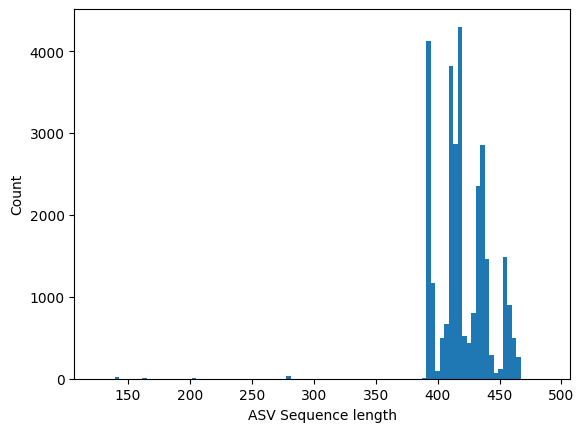

In [11]:
""" Compute the max sequence length. """
MAX_ASV_SEQUENCE_LEN = max(len(s) for s in asv_seqs_subset.values())
print("Max ASV sequence length:", MAX_ASV_SEQUENCE_LEN)

""" Plot ASV length frequency histogram """
fig, ax = plt.subplots(1, 1)
ax.hist([len(s) for s in asv_seqs_subset.values()], bins=100)
ax.set_xlabel("ASV Sequence length")
ax.set_ylabel("Count")

# Train-test split.

Splitting 1878 samples found in projects: ['PRJEB31155', 'PRJEB33905', 'PRJNA540406', 'PRJNA600229', 'PRJNA622517', 'PRJNA625181', 'PRJNA642894', 'PRJNA726866']


Sample pair calculation: 100%|███████████████████████████████████████████████████████████████████████████| 1762503/1762503 [00:18<00:00, 95549.94it/s]


Computed sample similarity matrix of shape (1878, 1878).
# ASV-connected components: 6
component sample count = 839
computing eigendecomposition.
eigenvalues: [1.01536826e-13 1.83847428e+01]
Using tail cutoff quantiles q_left = 0.1, q_right = 0.6
Partition is 84 vs. 336 [Cut weights: mean=0.13935353641127934, median=0.14052287581699346, max=0.31222707423580787, min=0.0034129692832764505]
component sample count = 324
computing eigendecomposition.
eigenvalues: [2.09544456e-15 3.96173516e+00]
Using tail cutoff quantiles q_left = 0.1, q_right = 0.6
Partition is 33 vs. 130 [Cut weights: mean=0.04435409031244233, median=0.041463414634146344, max=0.18716577540106952, min=0.002551020408163265]
component sample count = 253
computing eigendecomposition.
eigenvalues: [-4.53611182e-16  2.78216032e+01]
Using tail cutoff quantiles q_left = 0.1, q_right = 0.6
Partition is 26 vs. 101 [Cut weights: mean=0.08713240472453321, median=0.08433734939759036, max=0.21875, min=0.014705882352941176]
component sa

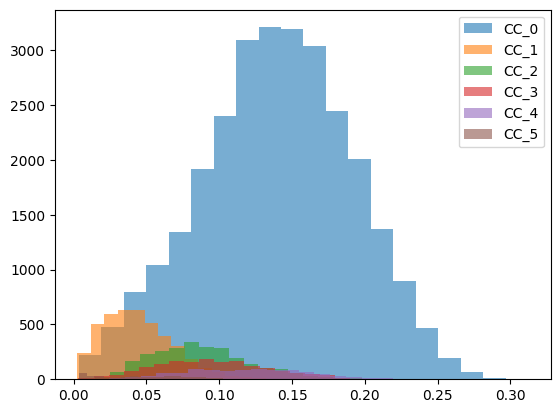

# train samples: 752
# test samples: 191
Ratio: 752 / 191 = 3.93717277486911


In [12]:
train_df, test_df = train_test_split_mincut_approximation(
    sample_df=sample_subset, 
    abundance_table_dir=abundance_table_dir,
    asv_id_subset=set(asv_seqs_subset.keys()), 
    train_fraction=0.4, 
    test_fraction=0.1,
)
train_df.to_csv(NOTEBOOK_CACHE / "train.tsv", sep="\t", index=False)
test_df.to_csv(NOTEBOOK_CACHE / "test.tsv", sep="\t", index=False)
    
print("# train samples: {}".format(train_df.shape[0]))
print("# test samples: {}".format(test_df.shape[0]))
print("Ratio: {} / {} = {}".format(
    train_df.shape[0], test_df.shape[0], train_df.shape[0] / test_df.shape[0]
))

In [13]:
train_df

,srs,project,srr,library_strategy,library_source,pubdate,total_bases,instrument,geo_loc_name,iso,region,read_counts
58,ERS3136842,PRJEB31155,ERR3148427,AMPLICON,METAGENOMIC,2020-04-25 00:15:31,100591190.0,Illumina MiSeq,NaN,unknown,unknown,30786
61,ERS3136839,PRJEB31155,ERR3148424,AMPLICON,METAGENOMIC,2020-04-25 00:15:31,94676540.0,Illumina MiSeq,NaN,unknown,unknown,25529
73,ERS3645293,PRJEB33905,ERR3472011,AMPLICON,METAGENOMIC,2021-07-16 20:56:42,121617846.0,Illumina MiSeq,NaN,unknown,unknown,175661
75,ERS3645291,PRJEB33905,ERR3472009,AMPLICON,METAGENOMIC,2021-07-16 20:56:42,53655658.0,Illumina MiSeq,NaN,unknown,unknown,78397
76,ERS3645290,PRJEB33905,ERR3472008,AMPLICON,METAGENOMIC,2021-07-16 20:56:42,94372530.0,Illumina MiSeq,NaN,unknown,unknown,138297
...,...,...,...,...,...,...,...,...,...,...,...,...
2145,SRS8850282,PRJNA726866,SRR14413724,AMPLICON,GENOMIC,2021-05-03 22:33:05,5427390.0,Illumina MiSeq,italy,IT,Europe and Northern America,10996
2147,SRS8850257,PRJNA726866,SRR14413746,AMPLICON,GENOMIC,2021-05-03 22:33:05,4960896.0,Illumina MiSeq,italy,IT,Europe and Northern America,9515
2148,SRS8850589,PRJNA726866,SRR14413416,AMPLICON,GENOMIC,2021-05-03 22:30:55,2717133.0,Illumina MiSeq,italy,IT,Europe and Northern America,5295
2149,SRS8850577,PRJNA726866,SRR14413427,AMPLICON,GENOMIC,2021-05-03 22:33:11,5766680.0,Illumina MiSeq,italy,IT,Europe and Northern America,11336


In [14]:
project_subset

,project,link,amplicon,avg_length,bead_beating,kit,sample_type,condition,subjects,notes
38,PRJNA625181,https://doi.org/10.1038/s43587-021-00129-0,v3-v4,420.40,True,TIANamp Stool DNA Kit,stool,healthy,adults,NaN
70,PRJEB33905,https://doi.org/10.1128/mSystems.00179-21,v3-v4,401.41,False,"QIAamp DNA stool minikit (Qiagen, Hilden, Germ...",stool,healthy,adults,NaN
72,PRJEB31155,https://doi.org/10.1038/s41598-020-58719-8,v3-v4,402.95,True,QIAamp DNA Stool Mini Kit,stool,healthy,adults,NaN
152,PRJNA726866,https://doi.org/10.3390/nu13062081,v3-v4,414.64,True,"DNeasy Blood and Tissue Kit (QIAGEN, Hilden, G...",stool,healthy,adults,NaN
181,PRJNA622517,https://doi.org/10.3389/fmicb.2020.585428,v3-v4,414.02,True,QiAmp mini DNA extraction kit (Qiagen),stool,healthy,adults,NaN
200,PRJNA540406,https://doi.org/10.1038/s41522-020-0119-0,v3-v4,410.93,False,NaN,stool,healthy,adults,NaN
254,PRJNA600229,https://doi.org/10.1038/s41598-021-96967-4,v3-v4,443.75,True,DNA Stool minikit (Qiagen),stool,healthy,adults,NaN
298,PRJNA642894,https://doi.org/10.3390/microorganisms9020358,v3-v4,443.11,True,"NucleoSpin Soil kit (Machery Nagel, D√ºren, Ge...",stool,healthy,adults,NaN
